In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from pandas import DataFrame

# Set a clean plotting style
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# read csv
reader = pd.read_csv('data/clustering_segmentation_Amz_Customers.csv')
df = DataFrame(reader)
display(df)

,Annual_Income_k,Spending_Score_1_100,Age,Frequency_of_Purchase
0,107,15,23,16
1,56,92,32,13
2,40,98,60,42
3,113,66,54,30
4,64,32,50,19
5,39,87,25,17
6,38,63,61,19
7,27,86,61,28
8,74,51,22,26
9,21,25,56,37


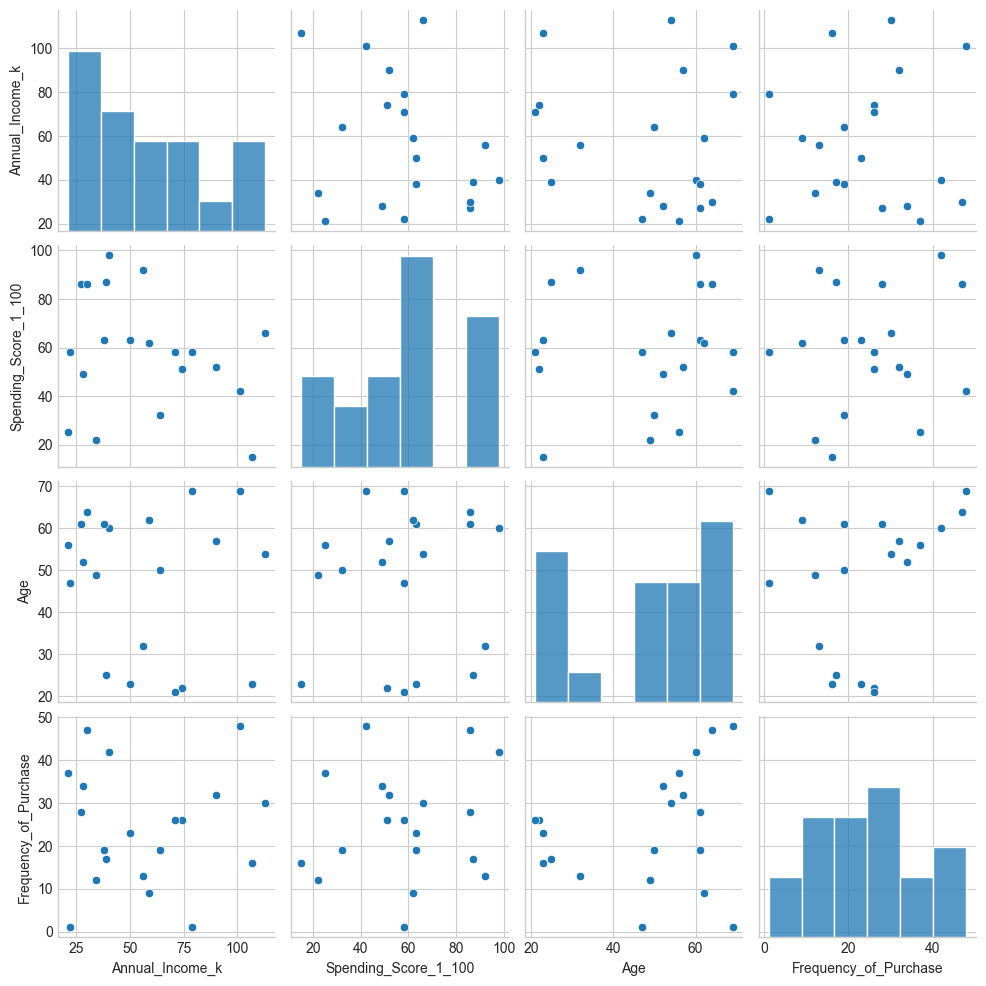

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your pandas DataFrame
sns.pairplot(df)
plt.show()

In [4]:
def plot_kmeans(k:int, X:DataFrame):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_

    print(f"labels: {labels}")
    print(f"Cluster Centers: {centers}")

    # --- SEABORN PAIR PLOT ADDITION ---

    # # 1. Convert the numpy array X into a Pandas DataFrame
    # # (Dynamically creates column names like Feature_1, Feature_2, etc.)
    # num_features = X.shape[1]
    # feature_names = [f"Feature_{i+1}" for i in range(num_features)]
    df = X

    # 2. Add the cluster labels as a new column so Seaborn can color-code them
    df['Cluster'] = labels

    # 3. Generate the pairplot
    # 'hue' applies the color based on the cluster assignment
    # 'palette' sets the color scheme, matching your original matplotlib 'viridis' choice
    # 'plot_kws' passes arguments down to the underlying scatter plots (like transparency)
    g = sns.pairplot(df, hue='Cluster', palette='viridis',

                 plot_kws={'alpha': 0.7})

    # 4. OVERLAY THE BOUNDARIES (Contours)
    # map_offdiag applies this specifically to the scatterplot panels (not the histograms)
    # levels=3 means it will draw 3 boundary rings per cluster
    g.map_offdiag(sns.kdeplot, levels=1, alpha=0.7)

    # 5. Add a title and display
    # y=1.02 shifts the title up slightly so it doesn't overlap the top graphs
    plt.suptitle(f'K-Means Clustering Pair-Plot (K={k})', y=1.02)
    plt.legend()
    plt.show()

labels: [1 0 0 1 1 0 2 0 1 2 1 0 2 2 1 2 0 2 1 1]
Cluster Centers: [[40.33333333 85.33333333 44.16666667 28.33333333]
 [87.375      46.75       45.625      24.75      ]
 [33.66666667 46.5        54.5        18.66666667]]


C:\Users\Sujeet\AppData\Local\Temp\ipykernel_30384\1965990494.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


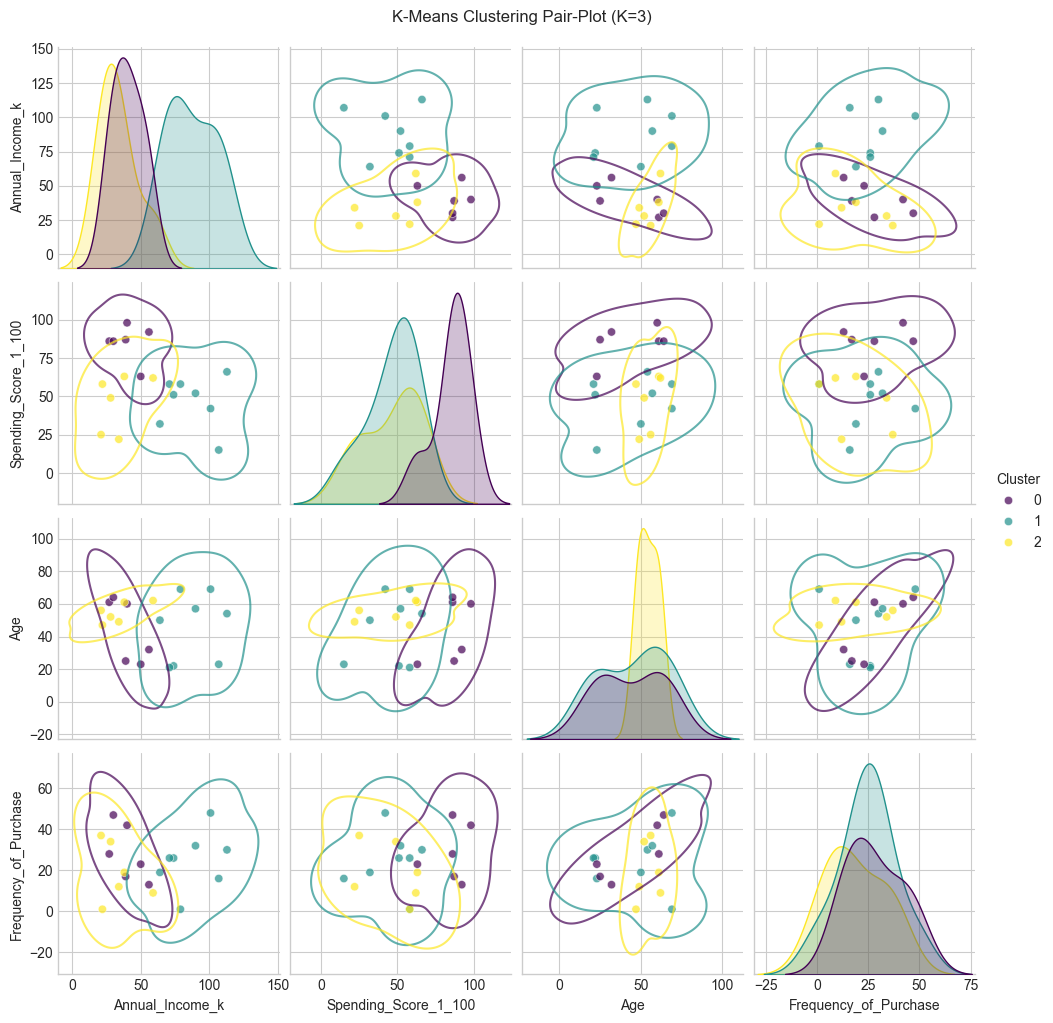

In [5]:
plot_kmeans(3, df)

In [6]:
# Calculate WCSS for various values of K (1 to 10)
def plot_elbow(df):
    wcss = []
    k_range = range(1, 11)

    for k in k_range:
        # Initialize KMeans with k clusters, using k-means++ for smarter initialization
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

        # Fit the model to the data
        # NOTE: Replace 'X' with the actual variable name of your processed data (e.g., df or X_scaled)
        kmeans.fit(df)

        # Append the WCSS (inertia) to the list
        wcss.append(kmeans.inertia_)

    # Plot the Elbow diagram
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)
    plt.title('Elbow Method For Optimal K', fontsize=14)
    plt.xlabel('Number of Clusters (K)', fontsize=12)
    plt.ylabel('WCSS', fontsize=12)
    plt.xticks(k_range)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

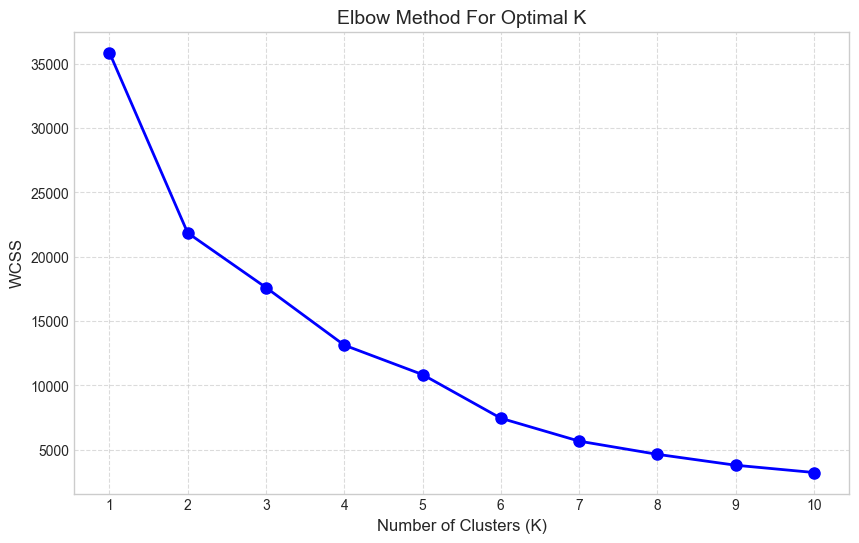

In [7]:
plot_elbow(df)